In [54]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [55]:
def integrate(f, xt, t, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    dyn: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt, t)
    k2 = dt * f(xt+k1/2., t + dt/2.)
    k3 = dt * f(xt+k2/2., t + dt/2.)
    k4 = dt * f(xt+k3, t + dt)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        t = tvec[i]
        xtraj[:,i]=integrate(f,x,t,dt)
        x = np.copy(xtraj[:,i])
    return xtraj, tvec

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2042142/646551329.py:2: SyntaxWarning: invalid escape sequence '\d'
  """
/tmp/ipykernel_2042142/646551329.py:31: SyntaxWarning: invalid escape sequence '\d'
  """


In [56]:
t, G ,J_cap, N, tau_m, k_d = sym.symbols(r't, G, J_{cap}, N, \tau_m, K_d')
J_jaw = N * J_cap

# J_1 = 1/2 * m1 * r1**2
# J_2 = 1/2 * m2 * r2**2

th1 = sym.Function(r'\theta_1')(t)
th2 = sym.Function(r'\theta_2')(t)
q = sym.Matrix([th1, th2])
q_dot = q.diff(t)
q_ddot = q_dot.diff(t)

# Relationship between the two pulleys
print("The gear ratio relationship between the two pulleys:")
display(sym.Eq(q_dot[0] / q_dot[1], G))

print("The inertia ratio relationship between the two pulleys:")
display(sym.Eq(sym.Symbol('J_jaw'), J_jaw))

# Kinetic energy of the system
KE = 1/2 * J_cap * q_dot[0]**2 + 1/2 * J_jaw* q_dot[1]**2
# print("\nThe kinetic energy of the system:")
# display(sym.Eq(sym.Symbol('KE'),KE))

# Substitute the gear ratio into expression
q_dot[1] = q_dot[0] / G

# Kinetic energy of the system with gear ratio substituted
KE = 1/2 * J_cap * q_dot[0]**2 + 1/2 * J_jaw* q_dot[1]**2

print("The kinetic energy of the system with the gear and inertia ratio substituted:")
display(sym.Eq(sym.Symbol('KE'),KE))

# Ignoring potential energy for now
L = KE

dLdq = L.diff(q[0])
dLdq_dot = L.diff(q_dot[0])
d_dLdq_dot_dt = dLdq_dot.diff(t)

lhs = d_dLdq_dot_dt - dLdq
rhs = tau_m - k_d * q_dot[0]

print("\nThe equation of motion when driving the capstan:")
eqn = sym.Eq(lhs, rhs)
display(sym.simplify(sym.nsimplify(eqn)))
soln_cap = sym.solve(eqn, q_ddot[0])
print("\nThe solution for the acceleration of the capstan:")
display(soln_cap[0])

print("The solution for the acceleration of the jaw:")
soln2 = soln_cap[0] / G
display(soln2)

J_eq = sym.simplify((tau_m - k_d * q_dot[0]) / soln_cap[0])
print("Reflected inerta at the motor:")
display(sym.Eq(sym.Symbol('J_eq,cap'), J_eq))


The gear ratio relationship between the two pulleys:


Eq(Derivative(\theta_1(t), t)/Derivative(\theta_2(t), t), G)

The inertia ratio relationship between the two pulleys:


Eq(J_jaw, J_{cap}*N)

The kinetic energy of the system with the gear and inertia ratio substituted:


...

G**2*(-K_d*Derivative(\theta_1(t), t) + \tau_m)/(J_{cap}*(G**2 + N))

The solution for the acceleration of the jaw:


G*(-K_d*Derivative(\theta_1(t), t) + \tau_m)/(J_{cap}*(G**2 + N))

Reflected inerta at the motor:


Eq(J_eq,cap, J_{cap} + J_{cap}*N/G**2)

In [57]:
tau_jaw = sym.symbols(r'\tau_{jaw}')

q_j = sym.Matrix([th2, th1])
q_dot_j = q_j.diff(t)
q_ddot_j = q_dot_j.diff(t)
q_dot_j[1] = q_dot_j[0] * G

KE_j = 1/2 * J_jaw * q_dot_j[0]**2 + 1/2 * J_cap * q_dot_j[1]**2
L_j = KE_j 

dLdq_j = L_j.diff(q_j[0])
dLdq_dot_j = L_j.diff(q_dot_j[0])
d_dLdq_dot_dt_j = dLdq_dot_j.diff(t)

eqn_j = sym.Eq(d_dLdq_dot_dt_j - dLdq_j, tau_jaw - k_d * G**2 *q_dot_j[0])
print("The equation of motion when driving the jaw:")
display(sym.simplify(sym.nsimplify(eqn_j)))
soln_jaw = sym.solve(eqn_j, q_ddot_j[0])
print("The solution for the acceleration of the jaw:")
display(soln_jaw[0])

soln_jaw2 = soln_jaw[0] * G
print("The solution for the acceleration of the capstan:")
display(soln_jaw2)

J_eq_jaw = sym.simplify((tau_jaw - k_d * G**2 * q_dot_j[0]) / soln_jaw[0])
print("Reflected inerta at the jaw:")
display(sym.Eq(sym.Symbol('J_eq,jaw'), J_eq_jaw))

The equation of motion when driving the jaw:


Eq(J_{cap}*(G**2 + N)*Derivative(\theta_2(t), (t, 2)), -G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})

The solution for the acceleration of the jaw:


(-G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})/(J_{cap}*(G**2 + N))

The solution for the acceleration of the capstan:


G*(-G**2*K_d*Derivative(\theta_2(t), t) + \tau_{jaw})/(J_{cap}*(G**2 + N))

Reflected inerta at the jaw:


Eq(J_eq,jaw, J_{cap}*(G**2 + N))

In [58]:
# thetaddot1_num = sym.lambdify((J_cap, N, G, tau_m), soln_cap[0])
# thetaddot2_num = sym.lambdify((J_cap, N, G, tau_jaw), soln_jaw[0])

In [59]:
def make_dyn(J_cap_val, N_val, G_val, tau_amp, freq):
    def dyn(s, t):
        """
        System dynamics function (extended)

        Parameters
        ============
        s: NumPy array
            s = [theta1, theta1dot] is the extended system
            state vector, including the position and
            the velocity of the pulley

        Return
        ============
        sdot: NumPy array
            time derivative of input state vector,
            sdot = [theta1dot, theta1ddot]
        """
        # Call the lambdified functions with the current state s
        tau_val = tau_amp * np.sin(2 * np.pi * freq * t)
        thetaddot1_val = thetaddot1_num(J_cap_val, N_val, G_val, tau_val)

        # Return the derivatives
        return np.array([s[1], thetaddot1_val])
    return dyn

def make_dyn_jaw(J_cap_val, N_val, G_val, tau_amp, freq):
    def dyn_jaw(s, t):
        """
        System dynamics function (extended)

        Parameters
        ============
        s: NumPy array
            s = [theta2, theta2dot] is the extended system
            state vector, including the position and
            the velocity of the pulley

        Return
        ============
        sdot: NumPy array
            time derivative of input state vector,
            sdot = [theta2dot, theta2ddot]
        """
        # Call the lambdified functions with the current state s
        tau_val = tau_amp * np.sin(2 * np.pi * freq * t)
        thetaddot2_val = thetaddot2_num(J_cap_val, N_val, G_val, tau_val)

        # Return the derivatives
        return np.array([s[1], thetaddot2_val])
    return dyn_jaw

# No gear ratio and matched inertias
J_cap_val, N_val, G_val = 1.0, 1.0, 1.0
tau_amp = 0.24 # Torque amplitude (Nm) for motor
freq = 5.0

timestep = 0.00005
# define initial state
# Theta1 = 0, Theta_dot1 = 0
s0 = np.array([0,0])

dyn = make_dyn(J_cap_val, N_val, G_val, tau_amp, freq)
dyn_jaw = make_dyn_jaw(J_cap_val, N_val, G_val, tau_amp, freq)
traj1, time = simulate(dyn, s0, [0, 5], timestep, integrate)
traj_jaw, time = simulate(dyn_jaw, s0, [0, 5], timestep, integrate)
accel1 = np.gradient(traj1[1, :], timestep)
accel_jaw = np.gradient(traj_jaw[1, :], timestep)
print('\033[1mShape of traj: \033[0m', traj1.shape)

traj2 = np.array([traj1[0, :] / G_val, traj1[1, :] / G_val])
accel2 = np.gradient(traj2[1, :], timestep)


fig, ax1 = plt.subplots()

ax1.plot(time, traj1[0, :], color='tab:blue', label='Theta1 (pos)')
ax1.plot(time, traj2[0, :], color='tab:green', label='Theta2 (pos)')
# ax1.plot(time, accel1, color='tab:cyan', label='Theta1ddot (accel)')
# ax1.plot(time, accel2, color='tab:purple', label='Theta2ddot (accel)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angle (rad)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(time, traj1[1, :], color='tab:orange', label='Theta1dot (vel)')
ax2.plot(time, traj2[1, :], color='tab:red', label='Theta2dot (vel)')
ax2.set_ylabel('Velocity (rad/s)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Angle and velocity vs time (G={G_val}, N={N_val})')
fig.tight_layout()
plt.show()

NameError: name 'thetaddot1_num' is not defined

In [ ]:
# Isolate the last 2 seconds (assuming freq = 5.0 Hz, 2s = 10 full cycles)
steady_state_time = 2.0 
tail_idx = time > (time[-1] - steady_state_time)

time_tail = time[tail_idx]
pos_tail = traj1[0, tail_idx]
vel_tail = traj1[1, tail_idx]
accel_tail = accel1[tail_idx]

# Generate the ideal input torque for this exact time tail
input_torque = tau_amp * np.sin(2 * np.pi * freq * time_tail)

def extract_bode_data(time_array, input_wave, output_wave, frequency, timestep):
    """Detrends output, calculates amplitude, and finds phase shift in degrees."""
    # Remove DC offset / ramp drift
    out_detrended = signal.detrend(output_wave)
    
    # Amplitude
    amplitude = (np.max(out_detrended) - np.min(out_detrended)) / 2.0
    
    # Phase Shift (Cross-Correlation)
    correlation = signal.correlate(out_detrended, input_wave, mode='full')
    lags = signal.correlation_lags(len(out_detrended), len(input_wave), mode='full')
    
    # Find the lag index of maximum correlation
    lag_idx = lags[np.argmax(correlation)]
    
    # Convert lag index to time delay, then to degrees
    time_delay = lag_idx * timestep
    phase_deg = (time_delay * frequency * 360) % 360
    
    # Keep phase bounded between 180 and -180
    if phase_deg > 180:
        phase_deg -= 360
        
    return amplitude, phase_deg

# Extract Position Data
pos_amp, pos_phase = extract_bode_data(time_tail, input_torque, pos_tail, freq, timestep)
print(f"Position     -> Amplitude: {pos_amp:.4f} rad,   Phase: {pos_phase:.1f} deg")

# Extract Velocity Data
vel_amp, vel_phase = extract_bode_data(time_tail, input_torque, vel_tail, freq, timestep)
print(f"Velocity     -> Amplitude: {vel_amp:.4f} rad/s, Phase: {vel_phase:.1f} deg")

# Extract Acceleration Data
accel_amp, accel_phase = extract_bode_data(time_tail, input_torque, accel_tail, freq, timestep)
print(f"Acceleration -> Amplitude: {accel_amp:.4f} rad/s^2, Phase: {accel_phase:.1f} deg")

Position     -> Amplitude: 0.0001 rad,   Phase: 179.9 deg
Velocity     -> Amplitude: 0.0038 rad/s, Phase: 89.0 deg
Acceleration -> Amplitude: 0.1297 rad/s^2, Phase: -0.1 deg


In [ ]:
def run_frequency_sweep(dyn_func, J1_val, n_val, G_val, tau_amp, freq_sweep, timestep=0.0005, sim_time=2.0, tail_frac=0.25):
    """
    Sweeps the input torque frequency for one (J1, n, G) parameter set and
    extracts the Bode magnitude/phase of theta1 (motor-side) position,
    velocity, and acceleration at each frequency.

    tail_frac sets the steady-state window as a fraction of sim_time, but is
    floored at 2 full cycles of the current frequency -- the original fixed
    0.5s tail window was less than one cycle at the low end of a 1-100 Hz
    sweep, which made the correlation-based phase estimate unreliable there.
    """
    results = {k: [] for k in ['amps_pos', 'phases_pos', 'amps_vel', 'phases_vel', 'amps_accel', 'phases_accel']}
    s0 = np.array([0.0, 0.0])
    for f in freq_sweep:
        dyn_f = dyn_func(J1_val, n_val, G_val, tau_amp, f)
        traj, t_vec = simulate(dyn_f, s0, [0, sim_time], timestep, integrate)
        accel = np.gradient(traj[1, :], timestep)

        tail_time = max(tail_frac * sim_time, 2.0 / f)
        tail_idx = t_vec > (t_vec[-1] - tail_time)
        input_wave = tau_amp * np.sin(2 * np.pi * f * t_vec[tail_idx])

        a_p, p_p = extract_bode_data(t_vec[tail_idx], input_wave, traj[0, tail_idx], f, timestep)
        a_v, p_v = extract_bode_data(t_vec[tail_idx], input_wave, traj[1, tail_idx], f, timestep)
        a_a, p_a = extract_bode_data(t_vec[tail_idx], input_wave, accel[tail_idx], f, timestep)

        results['amps_pos'].append(a_p); results['phases_pos'].append(p_p)
        results['amps_vel'].append(a_v); results['phases_vel'].append(p_v)
        results['amps_accel'].append(a_a); results['phases_accel'].append(p_a)
    return {k: np.array(v) for k, v in results.items()}

freq_sweep = np.logspace(0, 2, 40)  # 1-100 Hz

In [ ]:
from sympy import (
    diff, Function, Heaviside, inverse_laplace_transform,
    laplace_correspondence, laplace_initial_conds,
    laplace_transform, solve, symbols)

tau_jaw = F
s = symbols('s')

display(eqn_j)
lhs_laplace = laplace_transform(eqn_j.lhs, t, s, noconds=True)
rhs_laplace = laplace_transform(eqn_j.rhs, t, s, noconds=True)

display(lhs_laplace)
display(rhs_laplace)

Eq(1.0*G**2*J_{cap}*Derivative(\theta_2(t), (t, 2)) + 1.0*J_{cap}*N*Derivative(\theta_2(t), (t, 2)), -K_d*Derivative(\theta_2(t), t) + \tau_{jaw})

1.0*G**2*J_{cap}*(s**2*LaplaceTransform(\theta_2(t), t, s) - s*\theta_2(0) - Subs(Derivative(\theta_2(t), t), t, 0)) + 1.0*J_{cap}*N*(s**2*LaplaceTransform(\theta_2(t), t, s) - s*\theta_2(0) - Subs(Derivative(\theta_2(t), t), t, 0))

-K_d*(s*LaplaceTransform(\theta_2(t), t, s) - \theta_2(0)) + \tau_{jaw}/s

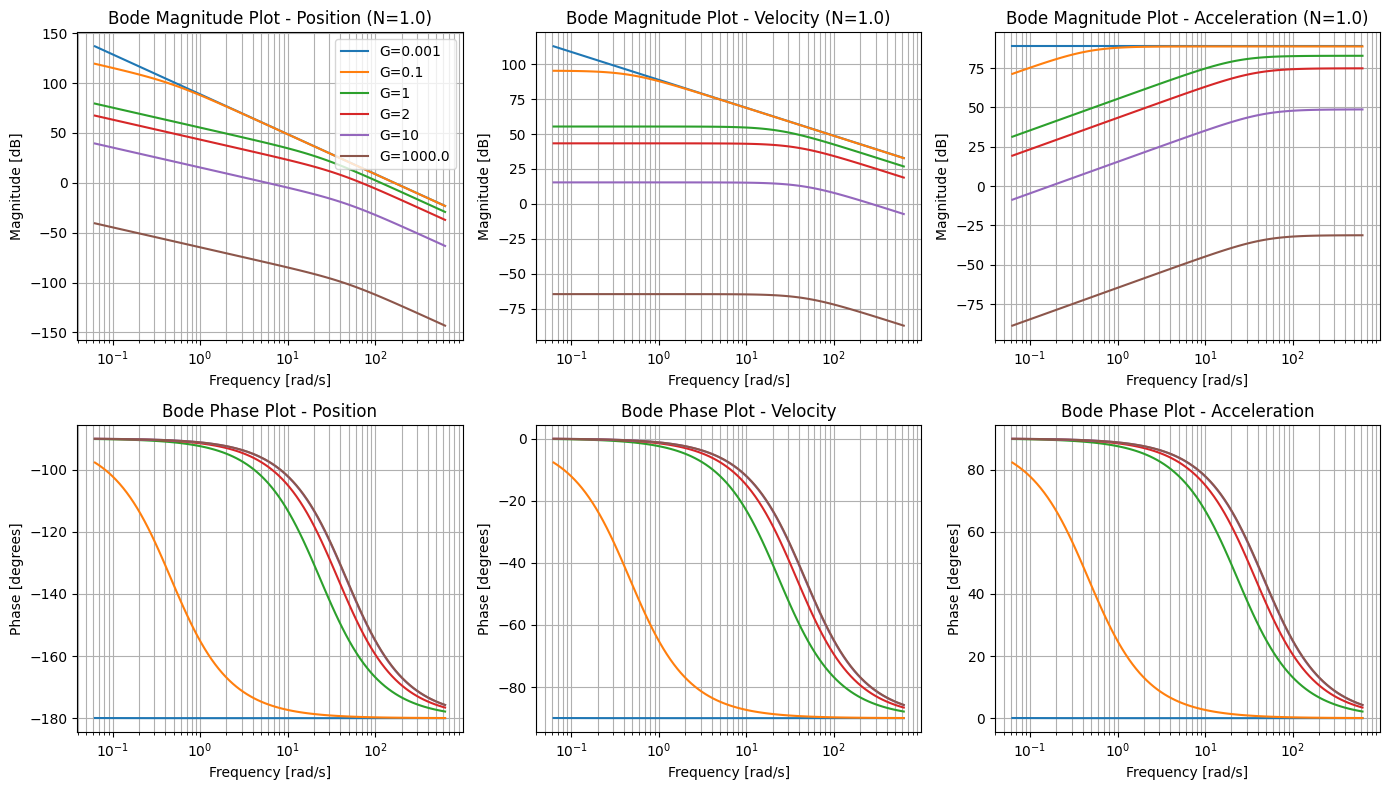

In [94]:

# System constants
J_cap = 3.55e-5 + 8.199e-7
N = 1.0  # Constant N of 1


# List of gear ratios to evaluate
G_values = [0.001, 0.1, 1, 2, 10, 1000.0]

# Setup frequency range
freq_hz = np.logspace(-2, 2, 100)
w = 2 * np.pi * freq_hz

# Setup plot
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
titles = ['Position', 'Velocity', 'Acceleration']

Kd = 0.0017

# Loop through each gear ratio
for G in G_values:
    # Calculate equivalent inertia for current G
    # J_eq = J_cap * (1 + N / G**2)  # This is for the motor
    J_eq = J_cap * (G**2 + N) # This is for the load side
    Kd_eq = Kd * G**2
    
    # Define transfer functions
    sys_pos = signal.TransferFunction([1], [J_eq, Kd_eq, 0])
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    sys_acc = signal.TransferFunction([1,0], [J_eq, Kd_eq])
    
    # Calculate Bode plots
    _, mag_pos, phase_pos = signal.bode(sys_pos, w)
    _, mag_vel, phase_vel = signal.bode(sys_vel, w)
    _, mag_acc, phase_acc = signal.bode(sys_acc, w)
    
    mags = [mag_pos, mag_vel, mag_acc]
    phases = [phase_pos, phase_vel, phase_acc]
    
    # Plot magnitudes and phases for this G
    for j in range(3):
        ax[0, j].semilogx(w, mags[j], label=f'G={G}')
        ax[1, j].semilogx(w, phases[j], label=f'G={G}')

# Formatting the plots (titles, labels, grids, legends)
for j in range(3):
    # Format Magnitude plots
    ax[0, j].set_title(f'Bode Magnitude Plot - {titles[j]} (N={N})')
    ax[0, j].set_xlabel('Frequency [rad/s]')
    ax[0, j].set_ylabel('Magnitude [dB]')
    ax[0, j].grid(True, which='both')
    if j == 0:
        ax[0, j].legend()  # Add legend to magnitude plots only for the first subplot
    
    # Format Phase plots
    ax[1, j].set_title(f'Bode Phase Plot - {titles[j]}')
    ax[1, j].set_xlabel('Frequency [rad/s]')
    ax[1, j].set_ylabel('Phase [degrees]')
    ax[1, j].grid(True, which='both')

fig.tight_layout()
plt.show()

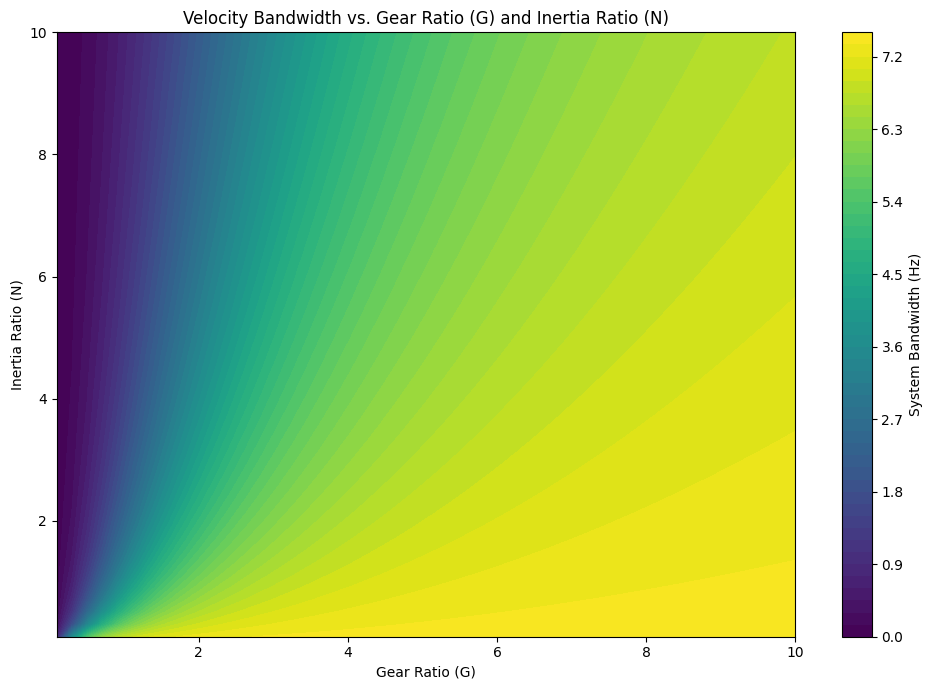

In [98]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def calculate_bandwidth(G, N, J_cap=3.63199e-5, Kd=0.0017):
    """
    Calculates the analytical -3dB bandwidth (in Hz) 
    for a given gear ratio (G) and inertia ratio (N).
    """
    J_eq = J_cap * (G**2 + N)
    Kd_eq = Kd * G**2
    
    # Velocity transfer function: H_vel(s) = 1 / (J_eq*s + Kd_eq)
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    
    # High-resolution frequency array (rad/s)
    w = np.logspace(-3, 4, 5000)
    w, mag, phase = signal.bode(sys_vel, w)
    
    # -3 dB threshold from DC gain (low-frequency reference)
    dc_gain_db = mag[0] 
    threshold_db = dc_gain_db - 3.0103
    
    # Interpolate to find the exact crossing frequency
    bandwidth_rads = np.interp(threshold_db, mag[::-1], w[::-1])
    bandwidth_hz = bandwidth_rads / (2 * np.pi)
    
    return bandwidth_hz

# 1. Define the ranges of G and N you want to evaluate
# Using more points (e.g., 50) creates a smoother heatmap
G_values = np.linspace(0.1, 10.0, 50) 
N_values = np.linspace(0.1, 10.0, 50)

# 2. Create a 2D matrix to store the results
bw_matrix = np.zeros((len(N_values), len(G_values)))

# 3. Loop through all combinations of G and N
for i, n in enumerate(N_values):
    for j, g in enumerate(G_values):
        bw_matrix[i, j] = calculate_bandwidth(g, n)

# 4. Generate the Contour Plot (Heatmap)
fig, ax = plt.subplots(figsize=(10, 7))

# Create meshgrid for plotting axes
G_grid, N_grid = np.meshgrid(G_values, N_values)

# Plot the surface
contour = ax.contourf(G_grid, N_grid, bw_matrix, levels=50, cmap='viridis')
cbar = fig.colorbar(contour)
cbar.set_label('System Bandwidth (Hz)')

# Formatting
ax.set_title('Velocity Bandwidth vs. Gear Ratio (G) and Inertia Ratio (N)')
ax.set_xlabel('Gear Ratio (G)')
ax.set_ylabel('Inertia Ratio (N)')

plt.tight_layout()
plt.show()

In [103]:
G_test, N_test = 2.0, 2.0
bw = calculate_bandwidth(G_test, N_test)
print(f"Bandwidth with G={G_test}, N={N_test}: {bw} rad/s")

Bandwidth with G=2.0, N=2.0: 4.966302334309676 rad/s


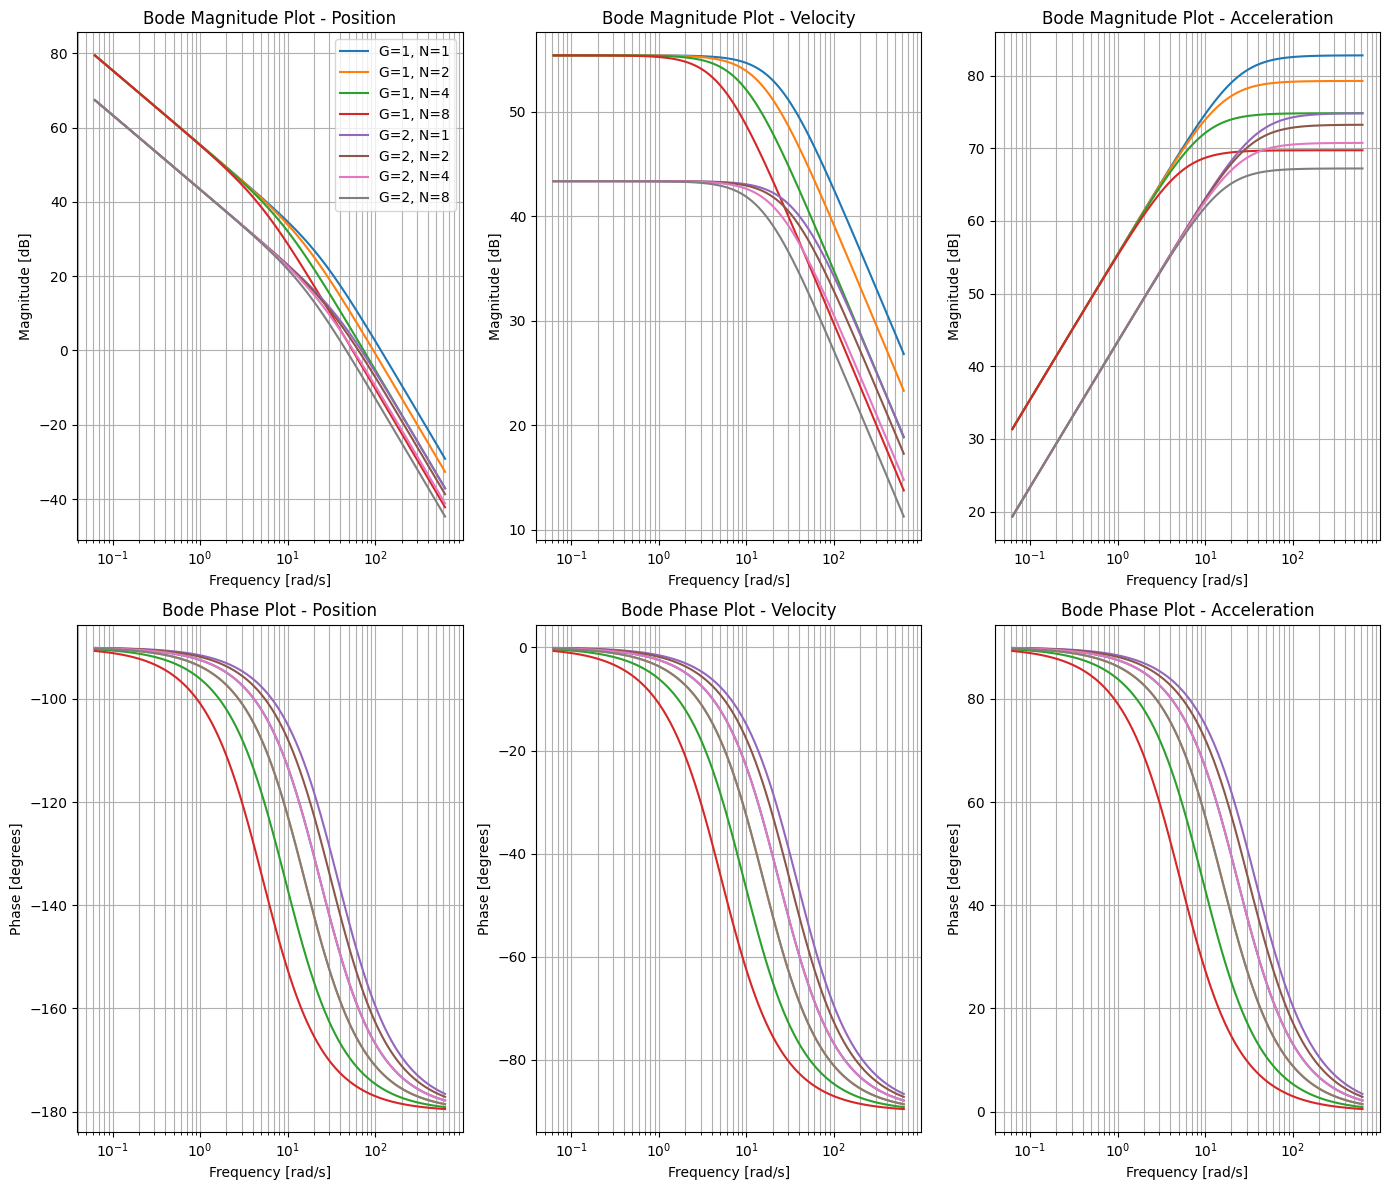

In [ ]:
# Define the combinations of G and n values
# combos = [(0.5,0.25), (1, 1), (2, 4), (4, 16)]
# combos = [(0.1, 1), (0.1, 0.01), (0.1, 2), (0.1, 4), (0.1, 8), (1,1), (1,2), (1,4), (1,8), (2,1), (2,2), (2,4), (2,8), (4,1), (4,2), (4,4), (4,8), (4,16)]
combos = [(1,1), (1,2), (1,4), (1,8), (2,1), (2,2), (2,4), (2,8),]

fig, ax = plt.subplots(2, 3, figsize=(14, 12))


for Gv, nv in combos:
    # Calculate equivalent inertia for current G
    # J_eq = J_cap * (1 + nv / Gv**2)  # This is for the motor
    J_eq = J_cap * (Gv**2 + nv) # This is for the load side
    Kd_eq = 0.0017 * Gv**2
    # Define transfer functions
    sys_pos = signal.TransferFunction([1], [J_eq, Kd_eq, 0])
    sys_vel = signal.TransferFunction([1], [J_eq, Kd_eq])
    sys_acc = signal.TransferFunction([1,0], [J_eq, Kd_eq])
    
    # Calculate Bode plots
    _, mag_pos, phase_pos = signal.bode(sys_pos, w)
    _, mag_vel, phase_vel = signal.bode(sys_vel, w)
    _, mag_acc, phase_acc = signal.bode(sys_acc, w)
    
    mags = [mag_pos, mag_vel, mag_acc]
    phases = [phase_pos, phase_vel, phase_acc]
    
    # Plot magnitudes and phases for this G
    for j in range(3):
        ax[0, j].semilogx(w, mags[j], label=f'G={Gv}, N={nv}')
        ax[1, j].semilogx(w, phases[j], label=f'G={Gv}, N={nv}')

# Formatting the plots (titles, labels, grids, legends)
for j in range(3):
    # Format Magnitude plots
    ax[0, j].set_title(f'Bode Magnitude Plot - {titles[j]}')
    ax[0, j].set_xlabel('Frequency [rad/s]')
    ax[0, j].set_ylabel('Magnitude [dB]')
    ax[0, j].grid(True, which='both')
    if j == 0:
        ax[0, j].legend()  # Add legend to magnitude plots only for the first subplot
    
    # Format Phase plots
    ax[1, j].set_title(f'Bode Phase Plot - {titles[j]}')
    ax[1, j].set_xlabel('Frequency [rad/s]')
    ax[1, j].set_ylabel('Phase [degrees]')
    ax[1, j].grid(True, which='both')

fig.tight_layout()
plt.show()

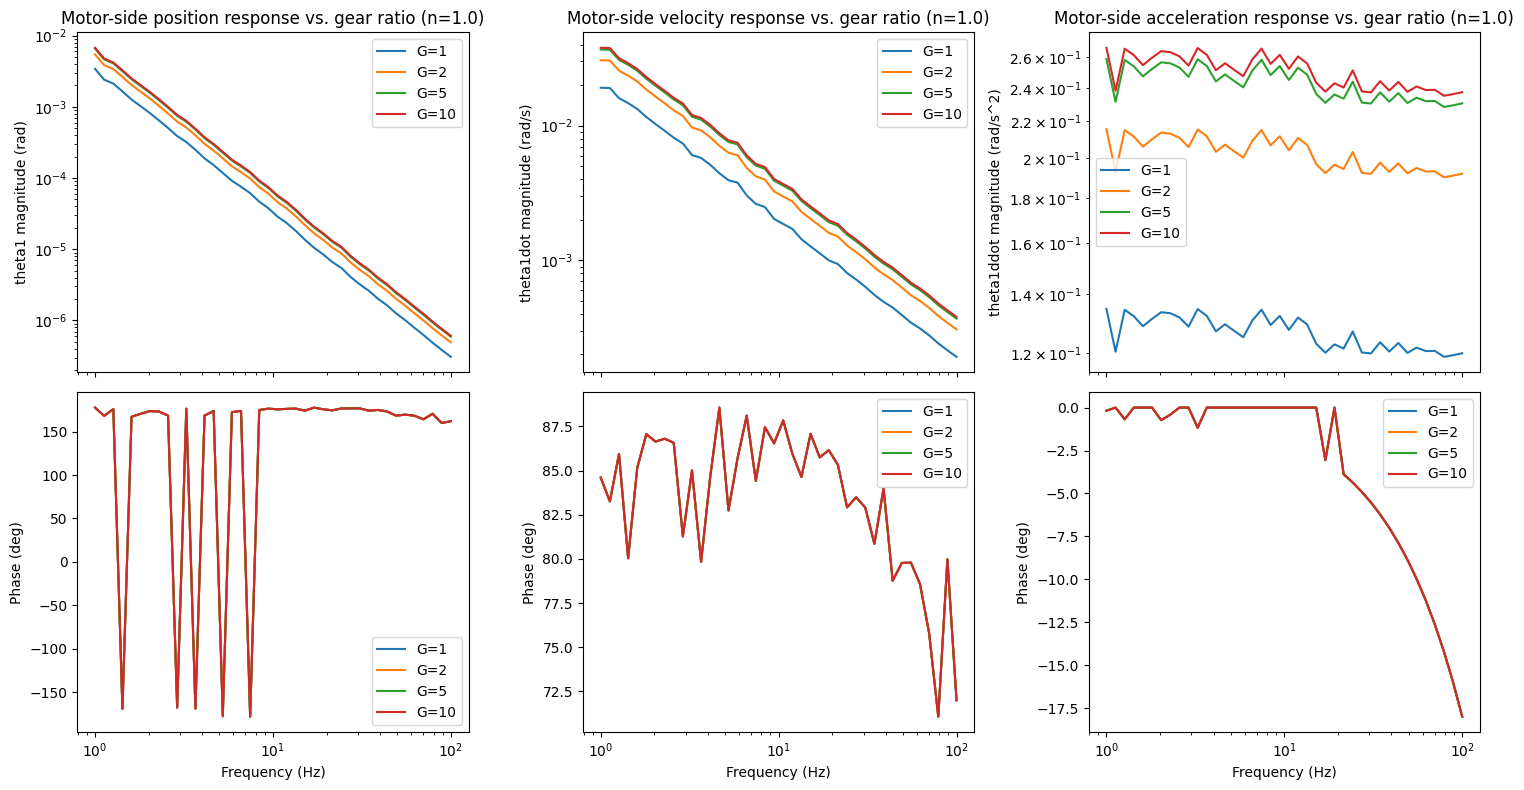

Equivalent inertia at the motor, J_eq = J1*(1 + n/G^2), with J1=1, n=1:
     G   J_eq (theory)   accel mag (theory)    accel mag (sim, mean)
     1          2.0000               0.1200                   0.1265
     2          1.2500               0.1920                   0.2024
     5          1.0400               0.2308                   0.2433
    10          1.0100               0.2376                   0.2505


In [ ]:
n_fixed = 1.0
G_values = [1, 2, 5, 10]
sweep_forward = {Gv: run_frequency_sweep(make_dyn, 1.0, n_fixed, Gv, tau_amp, freq_sweep) for Gv in G_values}


fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for Gv in G_values:
    ax[0,0].loglog(freq_sweep, sweep_forward[Gv]['amps_pos'], label=f'G={Gv}')
    ax[0,1].loglog(freq_sweep, sweep_forward[Gv]['amps_vel'], label=f'G={Gv}')
    ax[0,2].loglog(freq_sweep, sweep_forward[Gv]['amps_accel'], label=f'G={Gv}')
    ax[1,0].semilogx(freq_sweep, sweep_forward[Gv]['phases_pos'], label=f'G={Gv}')
    ax[1,1].semilogx(freq_sweep, sweep_forward[Gv]['phases_vel'], label=f'G={Gv}')
    ax[1,2].semilogx(freq_sweep, sweep_forward[Gv]['phases_accel'], label=f'G={Gv}')
ax[0,0].set_ylabel('theta1 magnitude (rad)')
ax[0,0].set_title(f'Motor-side position response vs. gear ratio (n={n_fixed})')
ax[0,0].legend()
ax[0,1].set_ylabel('theta1dot magnitude (rad/s)')
ax[0,1].set_title(f'Motor-side velocity response vs. gear ratio (n={n_fixed})')
ax[0,1].legend()
ax[0,2].set_ylabel('theta1ddot magnitude (rad/s^2)')
ax[0,2].set_title(f'Motor-side acceleration response vs. gear ratio (n={n_fixed})')
ax[0,2].legend()   
ax[1,0].set_ylabel('Phase (deg)')
ax[1,0].set_xlabel('Frequency (Hz)')
ax[1,0].legend()
ax[1,1].set_ylabel('Phase (deg)')
ax[1,1].set_xlabel('Frequency (Hz)')
ax[1,1].legend()
ax[1,2].set_ylabel('Phase (deg)')
ax[1,2].set_xlabel('Frequency (Hz)')
ax[1,2].legend()

fig.tight_layout()
plt.show()

print("Equivalent inertia at the motor, J_eq = J1*(1 + n/G^2), with J1=1, n=1:")
print(f"{'G':>6} {'J_eq (theory)':>15} {'accel mag (theory)':>20} {'accel mag (sim, mean)':>24}")
for Gv in G_values:
    Jeq = 1.0 * (1 + n_fixed / Gv**2)
    print(f"{Gv:>6} {Jeq:>15.4f} {tau_amp/Jeq:>20.4f} {np.mean(sweep_forward[Gv]['amps_accel']):>24.4f}")

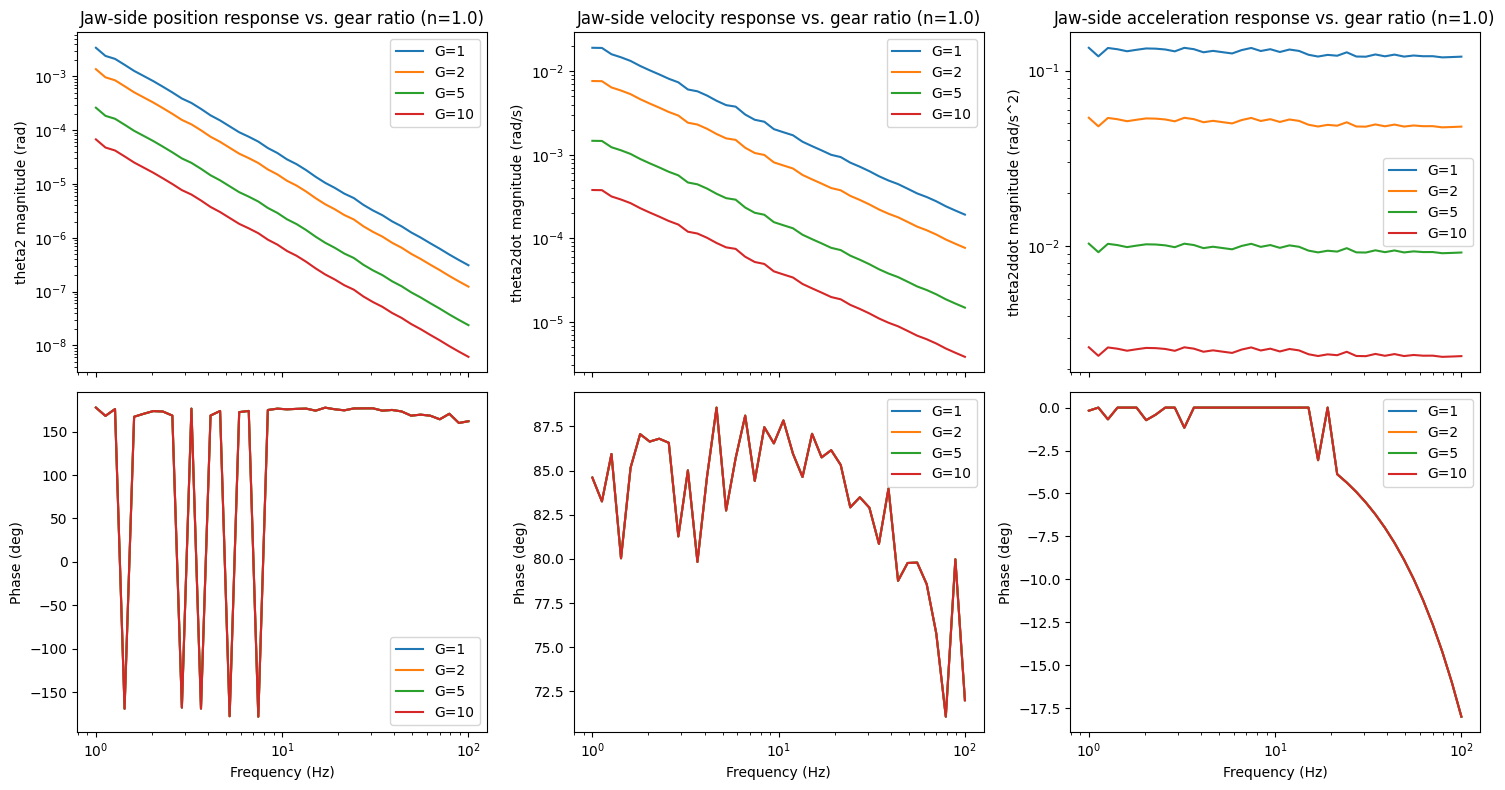

Equivalent inertia at the jaw, J_eq = J1*(G^2 + n), with J1=1, n=1:
     G   J_eq (theory)   accel mag (theory)    accel mag (sim, mean)
     1          2.0000               0.1200                   0.1265
     2          1.2500               0.1920                   0.2024
     5          1.0400               0.2308                   0.2433
    10          1.0100               0.2376                   0.2505


In [ ]:
sweep_backward = {Gv: run_frequency_sweep(make_dyn_jaw, 1.0, n_fixed, Gv, tau_amp, freq_sweep) for Gv in G_values}

fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for Gv in G_values:
    ax[0,0].loglog(freq_sweep, sweep_backward[Gv]['amps_pos'], label=f'G={Gv}')
    ax[0,1].loglog(freq_sweep, sweep_backward[Gv]['amps_vel'], label=f'G={Gv}')
    ax[0,2].loglog(freq_sweep, sweep_backward[Gv]['amps_accel'], label=f'G={Gv}')
    ax[1,0].semilogx(freq_sweep, sweep_backward[Gv]['phases_pos'], label=f'G={Gv}')
    ax[1,1].semilogx(freq_sweep, sweep_backward[Gv]['phases_vel'], label=f'G={Gv}')
    ax[1,2].semilogx(freq_sweep, sweep_backward[Gv]['phases_accel'], label=f'G={Gv}')
ax[0,0].set_ylabel('theta2 magnitude (rad)')
ax[0,0].set_title(f'Jaw-side position response vs. gear ratio (n={n_fixed})')
ax[0,0].legend()
ax[0,1].set_ylabel('theta2dot magnitude (rad/s)')
ax[0,1].set_title(f'Jaw-side velocity response vs. gear ratio (n={n_fixed})')
ax[0,1].legend()
ax[0,2].set_ylabel('theta2ddot magnitude (rad/s^2)')
ax[0,2].set_title(f'Jaw-side acceleration response vs. gear ratio (n={n_fixed})')
ax[0,2].legend()   
ax[1,0].set_ylabel('Phase (deg)')
ax[1,0].set_xlabel('Frequency (Hz)')
ax[1,0].legend()
ax[1,1].set_ylabel('Phase (deg)')
ax[1,1].set_xlabel('Frequency (Hz)')
ax[1,1].legend()
ax[1,2].set_ylabel('Phase (deg)')
ax[1,2].set_xlabel('Frequency (Hz)')
ax[1,2].legend()

fig.tight_layout()
plt.show()

print("Equivalent inertia at the jaw, J_eq = J1*(G^2 + n), with J1=1, n=1:")
print(f"{'G':>6} {'J_eq (theory)':>15} {'accel mag (theory)':>20} {'accel mag (sim, mean)':>24}")
for Gv in G_values:
    Jeq = 1.0 * (1 + n_fixed / Gv**2)
    print(f"{Gv:>6} {Jeq:>15.4f} {tau_amp/Jeq:>20.4f} {np.mean(sweep_forward[Gv]['amps_accel']):>24.4f}")

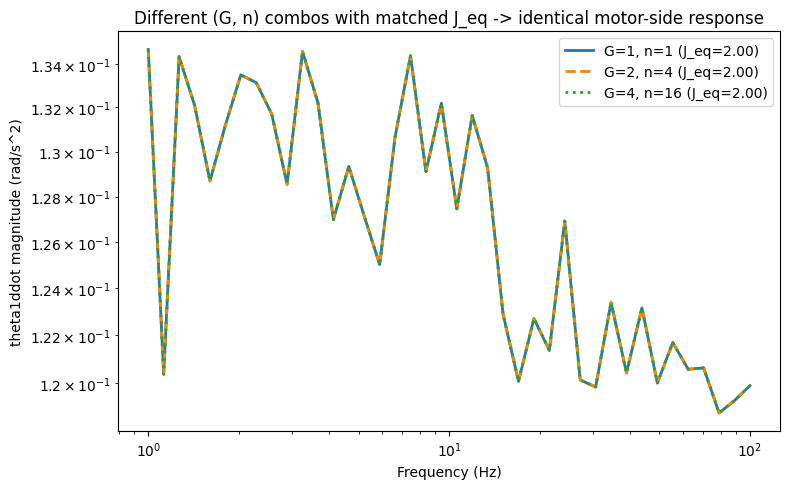

Same J_eq, different physical design -- the motor-referred response is identical:
  G= 1, n= 1  ->  mean accel magnitude = 0.1265 rad/s^2
  G= 2, n= 4  ->  mean accel magnitude = 0.1265 rad/s^2
  G= 4, n=16  ->  mean accel magnitude = 0.1265 rad/s^2

This equivalence is only in the motor-referred (theta1) response.


In [ ]:
combos = [(1, 1), (2, 4), (4, 16)]  # each gives J_eq = 2.0 with J1 = 1
sweep_by_combo = {(Gv, nv): run_frequency_sweep(make_dyn, 1.0, nv, Gv, tau_amp, freq_sweep) for (Gv, nv) in combos}

fig, ax = plt.subplots(figsize=(8, 5))
styles = ['-', '--', ':']
for (Gv, nv), ls in zip(combos, styles):
    Jeq = 1.0 * (1 + nv / Gv**2)
    ax.loglog(freq_sweep, sweep_by_combo[(Gv, nv)]['amps_accel'],
               linestyle=ls, linewidth=2, label=f'G={Gv}, n={nv} (J_eq={Jeq:.2f})')
ax.set_ylabel('theta1ddot magnitude (rad/s^2)')
ax.set_xlabel('Frequency (Hz)')
ax.set_title('Different (G, n) combos with matched J_eq -> identical motor-side response')
ax.legend()
fig.tight_layout()
plt.show()

print("Same J_eq, different physical design -- the motor-referred response is identical:")
for (Gv, nv) in combos:
    print(f"  G={Gv:>2}, n={nv:>2}  ->  mean accel magnitude = {np.mean(sweep_by_combo[(Gv, nv)]['amps_accel']):.4f} rad/s^2")

print()
print("This equivalence is only in the motor-referred (theta1) response.")


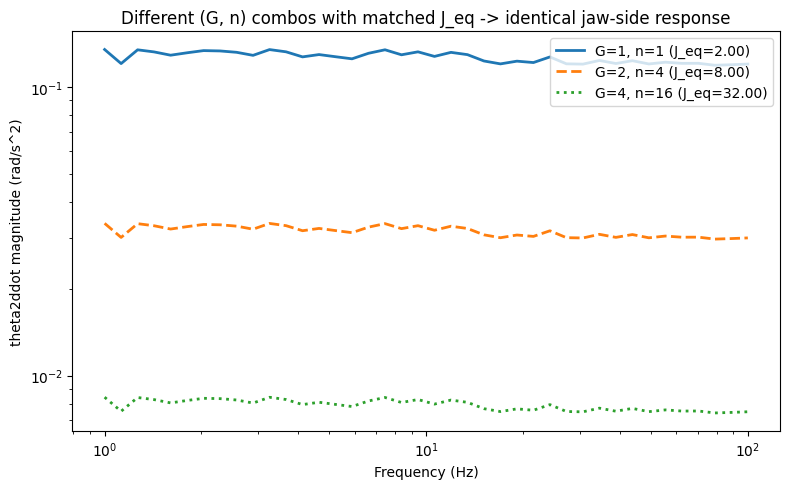

Same J_eq, different physical design -- the jaw-referred response is identical:
  G= 1, n= 1  ->  mean accel magnitude = 0.1265 rad/s^2
  G= 2, n= 4  ->  mean accel magnitude = 0.0316 rad/s^2
  G= 4, n=16  ->  mean accel magnitude = 0.0079 rad/s^2

This equivalence is only in the jaw-referred (theta2) response.


In [ ]:
combos = [(1, 1), (2, 4), (4, 16)]

sweep_by_combo = {(Gv, nv): run_frequency_sweep(make_dyn_jaw, 1.0, nv, Gv, tau_amp, freq_sweep) for (Gv, nv) in combos}

fig, ax = plt.subplots(figsize=(8, 5))
styles = ['-', '--', ':']
for (Gv, nv), ls in zip(combos, styles):
    Jeq = 1.0 * (Gv**2+ nv)
    ax.loglog(freq_sweep, sweep_by_combo[(Gv, nv)]['amps_accel'],
               linestyle=ls, linewidth=2, label=f'G={Gv}, n={nv} (J_eq={Jeq:.2f})')
ax.set_ylabel('theta2ddot magnitude (rad/s^2)')
ax.set_xlabel('Frequency (Hz)')
ax.set_title('Different (G, n) combos with matched J_eq -> identical jaw-side response')
ax.legend()
fig.tight_layout()
plt.show()

print("Same J_eq, different physical design -- the jaw-referred response is identical:")
for (Gv, nv) in combos:
    print(f"  G={Gv:>2}, n={nv:>2}  ->  mean accel magnitude = {np.mean(sweep_by_combo[(Gv, nv)]['amps_accel']):.4f} rad/s^2")

print()
print("This equivalence is only in the jaw-referred (theta2) response.")

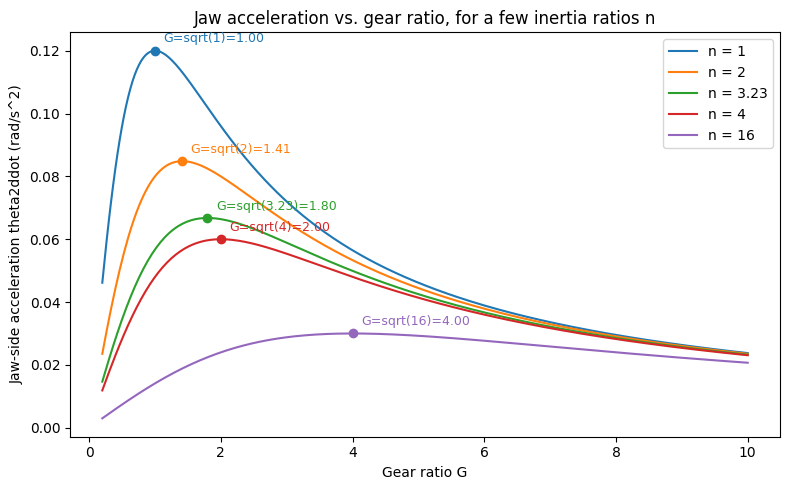

Inertia-matched gear ratio G = sqrt(n)  (equivalently n = G^2):
  n =   1  ->  G_opt = 1.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)
  n =   4  ->  G_opt = 2.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)
  n =  16  ->  G_opt = 4.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)


In [ ]:
G_range = np.linspace(0.2, 10, 300)

fig, ax = plt.subplots(figsize=(8, 5))
for n_val in [1, 2, 3.23, 4, 16]:
    theta1ddot = thetaddot1_num(1.0, n_val, G_range, tau_amp)  # J1 = 1
    theta2ddot = theta1ddot / G_range  # jaw-side (load) acceleration

    line, = ax.plot(G_range, theta2ddot, label=f'n = {n_val}')

    G_opt = np.sqrt(n_val)  # textbook: G = sqrt(J_load/J_motor) = sqrt(n)
    theta2ddot_opt = tau_amp / (1.0 * (G_opt + n_val / G_opt))
    ax.plot(G_opt, theta2ddot_opt, 'o', color=line.get_color())
    ax.annotate(f'G=sqrt({n_val})={G_opt:.2f}', (G_opt, theta2ddot_opt),
                textcoords='offset points', xytext=(6, 6), fontsize=9, color=line.get_color())

ax.set_xlabel('Gear ratio G')
ax.set_ylabel('Jaw-side acceleration theta2ddot (rad/s^2)')
ax.set_title('Jaw acceleration vs. gear ratio, for a few inertia ratios n')
ax.legend()
fig.tight_layout()
plt.show()

print("Inertia-matched gear ratio G = sqrt(n)  (equivalently n = G^2):")
for n_val in [1, 4, 16]:
    G_opt = np.sqrt(n_val)
    J2_reflected = 1.0 * n_val / G_opt**2
    print(f"  n = {n_val:>3}  ->  G_opt = {G_opt:.3f}   "
          f"(reflected load inertia at G_opt = J2/G_opt^2 = {J2_reflected:.3f} = J1, as expected)")